# Creating an electricity database with `shrecc.NewDatabase`

This notebook exercises the harmonized SHRECC workflow. The main example covers TYNDP data acquisition, reduced graph solving, premise activity mapping, temporal filtering, cutoff application, and Brightway database writing. A historical Energy Charts variant using the same class is included at the end. Intermediate volume data and normalized mixes remain available for inspection before anything is written.

In [1]:
from time import perf_counter

import bw2data as bd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from shrecc import NewDatabase

## Configuration

The default is a single 2040 run so the workflow can be checked quickly. Set `YEARS = [2035, 2040, 2050]` to create all three mapped tables. The month, day, and hour selection is transferred automatically to each requested year.

In [2]:
# Geographical and temporal scope of the inventories you want to create
COUNTRIES = ["ES", "FR", "DE", "IT", "PT", "BE", "NL", "LU", "AT", "CH"]
GENERAL_RANGE = ["2040-06-01 00:00:00", "2040-06-30 23:00:00"]
REFINED_RANGE = [10, 14]
FREQUENCY = "h"

# Brightway instructions
PROJECT_NAME = "SHRECCei311"
OUTPUT_DATABASE_NAME = "shrecc_tyndp_DE_{year}_june_noon"
WRITE_DATABASE = True  # Set to True only after inspecting the mapped tables.

# If prospective, TYNDP scenario, climate year, and year
SCENARIO = "DE"
CLIMATE_YEAR = 2009
YEARS = [2040]  # Use [2035, 2040, 2050] for the complete run.

# ...and the databases you match against for each year
PREMISE_DATABASES = {
    2035: "ei_cutoff_3.11_remind-eu_SSP2-PkBudg650_2035 2026-07-10",
    2040: "ei_cutoff_3.11_remind-eu_SSP2-PkBudg650_2040 2026-07-10",
    2050: "ei_cutoff_3.11_remind-eu_SSP2-PkBudg650_2050 2026-07-10",
}


## Brightway preflight

Creating tables does not modify any local Brightway database. The preflight only verifies that the configured project and year-specific premise databases are available.

In [3]:
bd.projects.set_current(PROJECT_NAME)

configured_backgrounds = {year: PREMISE_DATABASES[year] for year in YEARS}
missing_backgrounds = {
    year: name
    for year, name in configured_backgrounds.items()
    if name not in bd.databases
}
if missing_backgrounds:
    raise ValueError(f"Missing premise databases in {PROJECT_NAME!r}: {missing_backgrounds}")

# Display the databases against which each year will be mapped
pd.Series(configured_backgrounds, name="premise database").rename_axis("year").to_frame()

,premise database
year,
2040,ei_cutoff_3.11_remind-eu_SSP2-PkBudg650_2040 2...


## Configure the pipeline

`source="auto"` selects TYNDP for these prospective years. `strict=False` permits the location fallback while preserving the mapped source technology.

In [4]:
# A lot of arguments are optional, they are exposed here for transparency
elec_noon_june_2040 = NewDatabase(
    scenario=SCENARIO,
    years=YEARS,
    climate_year=CLIMATE_YEAR,
    premise_db=configured_backgrounds,
    iam="remind-eu",
    my_db_name=OUTPUT_DATABASE_NAME,
    countries=COUNTRIES,
    general_range=GENERAL_RANGE,
    refined_range=REFINED_RANGE,
    freq=FREQUENCY,
    project_name=PROJECT_NAME,
    source="auto",
    cutoff=1e-3,
    include_cutoff=True,
    strict=False,
    network=True,
    zero_consumption="month_hour_average",
    include_consumption_mix_volume=True,
    check=True,
    verbose=True,
)

elec_noon_june_2040

NewDatabase(years=[2040], sources={2040:tyndp})

In [5]:
pd.DataFrame(
    {
        "source": elec_noon_june_2040.sources,
        "background database": elec_noon_june_2040.background_databases,
        "output database": elec_noon_june_2040.database_names,
    }
).rename_axis("year")

,source,background database,output database
year,,,
2040,tyndp,ei_cutoff_3.11_remind-eu_SSP2-PkBudg650_2040 2...,shrecc_tyndp_DE_2040_june_noon


## Create mapped tables

This is the computational step. It may download and cache TYNDP source files, solve the selected hourly systems, map activities, and create the cutoff tables. It still does not write a Brightway database.

In [6]:
started = perf_counter()
elec_noon_june_2040.create()
elapsed = perf_counter() - started
print(f"Created {len(YEARS)} mapped table(s) in {elapsed:,.1f} seconds.")

Creating tyndp electricity mix for 2040
2026-07-22 11:45:41 Loading TYNDP pickle files
2026-07-22 11:45:42 Parsing hourly datetime index
2026-07-22 11:45:43 Loading technology and country mappings
2026-07-22 11:45:43 Aggregating hourly production by country and technology


D:\shrecc_project\shrecc\shrecc\tyndp.py:1159: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  production = production.groupby(


2026-07-22 11:45:43 Aggregating hourly trade to positive directional country flows


D:\shrecc_project\shrecc\shrecc\tyndp.py:305: UserWarning: Dropping trade columns without country-pair mappings: AT00-AT00EV, AT00-AT00RETE, AT00EV-AT00, AT00EV-AT00RETE, AT00RETE-AT00EV, BE00-BE00EV, BE00-BE00RETE, BE00EV-BE00, BE00EV-BE00RETE, BE00RETE-BE00EV
  trade_directional = _aggregate_tyndp_trade(trade, connections)


2026-07-22 11:45:43 Combining production and trade into Z_gross
2026-07-22 11:45:43 Built Z_gross with shape (8736, 547)
2026-07-22 11:45:44 Preparing canonical production and trade volumes
2026-07-22 11:45:44 Solving hourly country trade systems
2026-07-22 11:45:45 Built consumption results with sizes {'time': 720, 'producer_country': 35, 'technology': 31, 'exporter_country': 35, 'importer_country': 35, 'consumer_country': 35, 'source_country': 35}
Created 1 mapped table(s) in 5.7 seconds.


## Inspect canonical results

The result keeps production, trade, consumption, consumption-mix volume, and the normalized consumption mix. These data describe the full `GENERAL_RANGE`; `REFINED_RANGE` is applied when producing the database table.

In [7]:
YEAR_TO_INSPECT = YEARS[0]
results = elec_noon_june_2040.results(YEAR_TO_INSPECT)
results

<xarray.Dataset> Size: 451MB
Dimensions:                 (time: 720, producer_country: 35, technology: 31,
                             exporter_country: 35, importer_country: 35,
                             consumer_country: 35, source_country: 35)
Coordinates:
  * time                    (time) datetime64[ns] 6kB 2040-06-01 ... 2040-06-...
  * producer_country        (producer_country) object 280B 'AL' 'AT' ... 'UK'
  * technology              (technology) object 248B 'Gas CCGT CCS [MW]' ... ...
  * exporter_country        (exporter_country) object 280B 'AL' 'AT' ... 'UK'
  * importer_country        (importer_country) object 280B 'AL' 'AT' ... 'UK'
  * consumer_country        (consumer_country) object 280B 'AL' 'AT' ... 'UK'
  * source_country          (source_country) object 280B 'AL' 'AT' ... 'SK' 'UK'
Data variables:
    production_volume       (time, producer_country, technology) int64 6MB 0 ...
    trade_volume            (time, exporter_country, importer_country) int64 7MB ...
    consumption_volume      (time, consumer_country) int64 202kB 722 ... 50150
    consumption_mix         (time, consumer_country, source_country, technology) float64 219MB ...
    consumption_mix_volume  (time, consumer_country, source_country, technology) float64 219MB ...
Attributes:
    volume_unit:                MWh
    solver:                     country_trade_block
    consumption_volume_source:  Demand [MW] (losses included)

In [8]:
origin_dimensions = ["source_country", "technology"]
mix_total = results["consumption_mix"].sum(origin_dimensions)
positive_consumption = results["consumption_volume"] > 0
normalization_error = float(
    abs(mix_total.where(positive_consumption) - 1).max(skipna=True)
)

volume_error = float(
    abs(
        results["consumption_mix_volume"].sum(origin_dimensions)
        - results["consumption_volume"]
    ).max(skipna=True)
)

checks = pd.Series(
    {
        "maximum mix normalization error": normalization_error,
        "maximum consumption-volume error (MWh)": volume_error,
    },
    name="value",
)
display(checks.to_frame())
assert normalization_error < 1e-8
assert volume_error < 1e-6

,value
maximum mix normalization error,4.440892e-16
maximum consumption-volume error (MWh),2.910383e-11


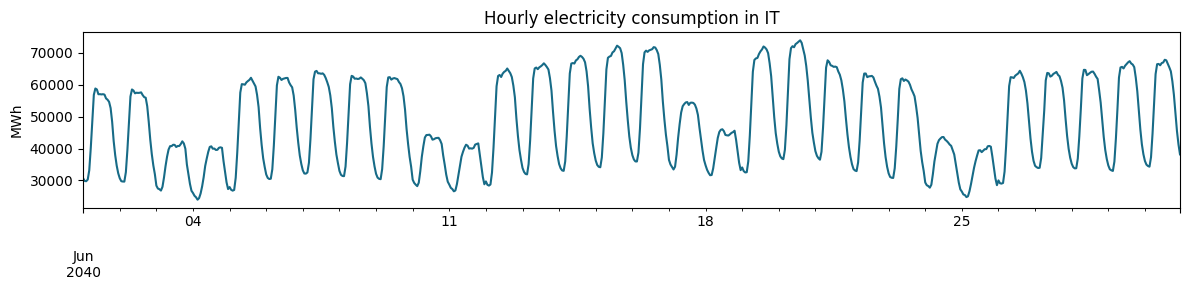

In [9]:
COUNTRY_TO_INSPECT = "IT"

ax = (
    results["consumption_volume"]
    .sel(consumer_country=COUNTRY_TO_INSPECT)
    .to_series()
    .plot(figsize=(12, 3), color="#176B87")
)
ax.set(
    title=f"Hourly electricity consumption in {COUNTRY_TO_INSPECT}",
    xlabel="",
    ylabel=results.attrs.get("volume_unit", "MWh"),
)
plt.tight_layout()

### Offshore-wind check

This specifically checks the Italian offshore-wind, which does not exist in ecoinvent and therefore cannot be mapped directly to `electricity production, wind, 1-3MW turbine, offshore {IT}` (many similar cases can be found for other countries), and should fall back to the right IAM region, first in the solved volume data and then in the mapped premise table.

We can see in the next cell that Italy has a substantial production of offshore wind.

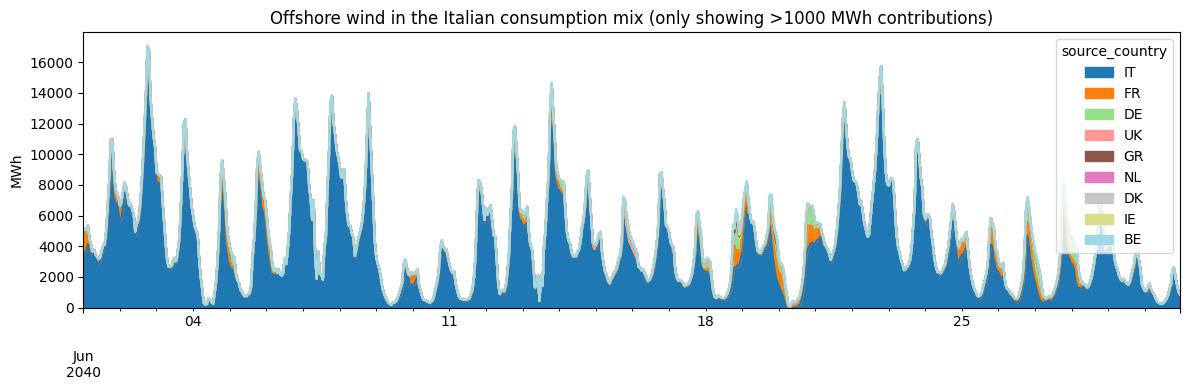

In [41]:
offshore_technologies = [
    technology
    for technology in results.coords["technology"].values
    if "offshore" in str(technology).lower()
]

if offshore_technologies:
    italian_offshore_volume = (
        results["consumption_mix_volume"]
        .sel(
            consumer_country=COUNTRY_TO_INSPECT,
            technology=offshore_technologies,
        )
        .sum(["technology"]).to_series().unstack()
    )

    italian_offshore_sum = italian_offshore_volume.sum()
    index_order = italian_offshore_sum[italian_offshore_sum>1000].sort_values(ascending=False).index

    italian_offshore_volume = italian_offshore_volume.loc[:,index_order]

    # display(italian_offshore_volume.describe().to_frame("MWh"))
    ax = italian_offshore_volume.plot.area(stacked=True, figsize=(12, 4), colormap="tab20")
    ax.set(title="Offshore wind in the Italian consumption mix (only showing >1000 MWh contributions)", xlabel="", ylabel="MWh")
    plt.tight_layout()
else:
    print("No offshore technology label was found in the solved result.")

## Inspect the mapped database table

Rows are premise or ecoinvent activities at their selected exchange geography. Columns are consuming countries. The table is already temporally filtered and has the configured cutoff applied.

In [42]:
# Here we should see the offshore wind mapping against the correct activity in region "ESC" (remind-eu geomap for "IT") instead of "IT"
database_table = elec_noon_june_2040.table(YEAR_TO_INSPECT)
display(database_table.sort_values(COUNTRY_TO_INSPECT, ascending=False).head(5))

column_totals = database_table.sum(axis=0)
display(column_totals.rename("exchange sum").to_frame().head())
np.testing.assert_allclose(column_totals, 1, atol=1e-8)

AT  \
geography activityName                                       product                   unit             
IT        electricity production, photovoltaic, commercial   electricity, high voltage kWh   0.000000   
          electricity production, hydro, run-of-river        electricity, high voltage kWh   0.000000   
          electricity production, wind, 1-3MW turbine, on... electricity, high voltage kWh   0.000000   
ESC       electricity production, wind, 1-3MW turbine, of... electricity, high voltage kWh   0.000000   
FR        electricity production, photovoltaic, commercial   electricity, high voltage kWh   0.001016   

                                                                                                   BE  \
geography activityName                                       product                   unit             
IT        electricity production, photovoltaic, commercial   electricity, high voltage kWh   0.000000   
          electricity production, hydro, run-of-river        electricity, high voltage kWh   0.000000   
          electricity production, wind, 1-3MW turbine, on... electricity, high voltage kWh   0.000000   
ESC       electricity production, wind, 1-3MW turbine, of... electricity, high voltage kWh   0.000000   
FR        electricity production, photovoltaic, commercial   electricity, high voltage kWh   0.082586   

                                                                                                   CH  \
geography activityName                                       product                   unit             
IT        electricity production, photovoltaic, commercial   electricity, high voltage kWh   0.013663   
          electricity production, hydro, run-of-river        electricity, high voltage kWh   0.000000   
          electricity production, wind, 1-3MW turbine, on... electricity, high voltage kWh   0.000000   
ESC       electricity production, wind, 1-3MW turbine, of... electricity, high voltage kWh   0.000000   
FR        electricity production, photovoltaic, commercial   electricity, high voltage kWh   0.077770   

                                                                                                   DE  \
geography activityName                                       product                   unit             
IT        electricity production, photovoltaic, commercial   electricity, high voltage kWh   0.000000   
          electricity production, hydro, run-of-river        electricity, high voltage kWh   0.000000   
          electricity production, wind, 1-3MW turbine, on... electricity, high voltage kWh   0.000000   
ESC       electricity production, wind, 1-3MW turbine, of... electricity, high voltage kWh   0.000000   
FR        electricity production, photovoltaic, commercial   electricity, high voltage kWh   0.006705   

                                                                                              ES  \
geography activityName                                       product                   unit        
IT        electricity production, photovoltaic, commercial   electricity, high voltage kWh   0.0   
          electricity production, hydro, run-of-river        electricity, high voltage kWh   0.0   
          electricity production, wind, 1-3MW turbine, on... electricity, high voltage kWh   0.0   
ESC       electricity production, wind, 1-3MW turbine, of... electricity, high voltage kWh   0.0   
FR        electricity production, photovoltaic, commercial   electricity, high voltage kWh   0.0   

                                                                                                   FR  \
geography activityName                                       product                   unit             
IT        electricity production, photovoltaic, commercial   electricity, high voltage kWh   0.000000   
          electricity production, hydro, run-of-river        electricity, high voltage kWh   0.000000   
          electricity production, 

,exchange sum
AT,1.0
BE,1.0
CH,1.0
DE,1.0
ES,1.0


In [43]:
activity_names = database_table.index.get_level_values("activityName").astype(str)
offshore_rows = database_table.loc[
    activity_names.str.contains("offshore", case=False, regex=False)
]
display(offshore_rows.loc[:, [COUNTRY_TO_INSPECT]].sort_values(COUNTRY_TO_INSPECT, ascending=False))

,,,,IT
geography,activityName,product,unit,
ESC,"electricity production, wind, 1-3MW turbine, offshore","electricity, high voltage",kWh,0.035153
FR,"electricity production, wind, 1-3MW turbine, offshore","electricity, high voltage",kWh,0.001596
BE,"electricity production, wind, 1-3MW turbine, offshore","electricity, high voltage",kWh,0.000000
DE,"electricity production, wind, 1-3MW turbine, offshore","electricity, high voltage",kWh,0.000000
ECE,"electricity production, wind, 1-3MW turbine, offshore","electricity, high voltage",kWh,0.000000
DK,"electricity production, wind, 1-3MW turbine, offshore","electricity, high voltage",kWh,0.000000
EE,"electricity production, wind, 1-3MW turbine, offshore","electricity, high voltage",kWh,0.000000
ECS,"electricity production, wind, 1-3MW turbine, offshore","electricity, high voltage",kWh,0.000000
ES,"electricity production, wind, 1-3MW turbine, offshore","electricity, high voltage",kWh,0.000000


In [44]:
# Check against which region the "offshore wind" activity is being matched
# Only countries with offshore wind in the latest ecoinvent version should be country-matched
exchange_geographies = elec_noon_june_2040.exchange_geography_maps[YEAR_TO_INSPECT]
offshore_activity_mask = exchange_geographies.index.astype(str).str.contains(
    "offshore", case=False, regex=False
)
display(exchange_geographies.loc[offshore_activity_mask, COUNTRIES])

source_country,ES,FR,DE,IT,PT,BE,NL,LU,AT,CH
premise_activity,,,,,,,,,,
"electricity production, wind, 1-3MW turbine, offshore",ES,FR,DE,ESC,PT,BE,NL,EWN,EWN,NEN


## Write the Brightway database

Set `WRITE_DATABASE = True` in the configuration cell and run the following cell after the checks above pass. Writing is intentionally separate from creation. An existing output database with the same name will be replaced.

In [31]:
if WRITE_DATABASE:
    existing_outputs = [
        name for name in elec_noon_june_2040.database_names.values() if name in bd.databases
    ]
    if existing_outputs:
        print(f"Replacing existing output databases: {existing_outputs}")

    started = perf_counter()
    elec_noon_june_2040.write()
    elapsed = perf_counter() - started
    print(f"Wrote {len(elec_noon_june_2040.written_database_names)} database(s) in {elapsed:,.1f} seconds.")
else:
    print("Database write skipped. Set WRITE_DATABASE = True when the tables are ready.")

Replacing existing output databases: ['shrecc_tyndp_DE_2040_june_noon']
Using fallback activity:electricity production, at co-generation oil-fired power plant, post, pipeline 200km, storage 1000m, RER for requested geography ESC
Using fallback activity:electricity production, at oil-fired power plant, combined cycle, oxy, pipeline 200km, storage 1000m, RER for requested geography ESC
Using fallback activity:electricity production, solar thermal parabolic trough, 50 MW, RoW for requested geography ESC
Using fallback activity:electricity production, solar tower power plant, 20 MW, RoW for requested geography ESC
Using fallback activity:electricity production, wind, 1-3MW turbine, offshore, RoW for requested geography ESC
Using fallback activity:electricity production, hydro, run-of-river, RoW for requested geography NEN
11:11:30+0200 [warning  ] Removing database node(s) from calculation setup tyndp_test


100%|██████████| 10/10 [00:00<00:00, 342.02it/s]


11:11:32+0200 [info     ] Vacuuming database            
Wrote 1 database(s) in 283.2 seconds.


In [33]:
if elec_noon_june_2040.written_database_names:
    bd.projects.set_current(PROJECT_NAME)
    written = pd.Series(
        {
            year: {
                "database": name,
                "activities": len(bd.Database(name)),
            }
            for year, name in elec_noon_june_2040.written_database_names.items()
        }
    )
    display(pd.DataFrame(written.to_dict()).T.rename_axis("year"))
else:
    print("No database has been written by this NewDatabase instance.")

,database,activities
year,,
2040,shrecc_tyndp_DE_2040_june_noon,10


## Historical Energy Charts variant

Historical years use the same interface. With `source="auto"`, a non-TYNDP year selects Energy Charts and maps the resulting consumption mix directly to the configured ecoinvent database. Enable this small example independently when needed.

In [45]:
RUN_HISTORICAL_EXAMPLE = True
HISTORICAL_YEAR = 2025
HISTORICAL_BACKGROUND_DATABASE = "ecoinvent-3.11-cutoff"

elec_noon_june_2025 = NewDatabase(
    years=HISTORICAL_YEAR,
    countries=COUNTRIES,
    project_name=PROJECT_NAME,
    premise_db=HISTORICAL_BACKGROUND_DATABASE,
    my_db_name=f"shrecc_energy_charts_{HISTORICAL_YEAR}_june_noon",
    general_range=[
        f"{HISTORICAL_YEAR}-06-01 00:00:00",
        f"{HISTORICAL_YEAR}-06-30 23:00:00",
    ],
    refined_range=[10, 14],
    freq="h",
    source="auto",
    cutoff=1e-3,
    include_cutoff=True,
    check=True,
    verbose=True,
)

elec_noon_june_2025

NewDatabase(years=[2025], sources={2025:energy_charts})

In [46]:
if RUN_HISTORICAL_EXAMPLE:
    if HISTORICAL_BACKGROUND_DATABASE not in bd.databases:
        raise ValueError(
            f"Missing {HISTORICAL_BACKGROUND_DATABASE!r} in project {PROJECT_NAME!r}"
        )
    elec_noon_june_2025.create()
    display(elec_noon_june_2025.table().nlargest(n=10, columns="FR"))
else:
    print("Historical example skipped. Set RUN_HISTORICAL_EXAMPLE = True to run it.")

Creating energy_charts electricity mix for 2025


C:\Users\Gibon\AppData\Local\Temp\ipykernel_18656\1732694544.py:6: UserWarning: Energy Charts activity mapping gaps for 2025 were assigned to source-country high-voltage markets. Mean fallback share by consumer: NL 72.4%, BE 12.1%, LU 4.6%, IT 4.5%, CH 3.6%. Largest source-technology gaps: NL/Others 70.3%, BE/Others 4.2%, IT/Others 4.2%, CH/Others 3.2%, LU/Waste non-renewable 1.9%. See mapping_report(2025) for the full report.
  elec_noon_june_2025.create()


AT  \
geography activityName                                       product                   unit             
FR        electricity production, nuclear, pressure water... electricity, high voltage kWh   0.001715   
          electricity production, photovoltaic, 3kWp slan... electricity, low voltage  kWh   0.000000   
          electricity production, hydro, run-of-river        electricity, high voltage kWh   0.000000   
          electricity production, photovoltaic, 3kWp slan... electricity, low voltage  kWh   0.000000   
          electricity production, photovoltaic, 570kWp op... electricity, low voltage  kWh   0.000000   
          electricity production, wind, 1-3MW turbine, on... electricity, high voltage kWh   0.000000   
          electricity production, hydro, reservoir, alpin... electricity, high voltage kWh   0.000000   
RER       market group for electricity, high voltage         electricity, high voltage kWh   0.025981   
FR        market for electricity, high voltage               electricity, high voltage kWh   0.000000   
          electricity production, natural gas, combined c... electricity, high voltage kWh   0.000000   

                                                                                                   BE  \
geography activityName                                       product                   unit             
FR        electricity production, nuclear, pressure water... electricity, high voltage kWh   0.019925   
          electricity production, photovoltaic, 3kWp slan... electricity, low voltage  kWh   0.003000   
          electricity production, hydro, run-of-river        electricity, high voltage kWh   0.002415   
          electricity production, photovoltaic, 3kWp slan... electricity, low voltage  kWh   0.002412   
          electricity production, photovoltaic, 570kWp op... electricity, low voltage  kWh   0.001872   
          electricity production, wind, 1-3MW turbine, on... electricity, high voltage kWh   0.001938   
          electricity production, hydro, reservoir, alpin... electricity, high voltage kWh   0.000000   
RER       market group for electricity, high voltage         electricity, high voltage kWh   0.014684   
FR        market for electricity, high voltage               electricity, high voltage kWh   0.000000   
          electricity production, natural gas, combined c... electricity, high voltage kWh   0.000000   

                                                                                                   CH  \
geography activityName                                       product                   unit             
FR        electricity production, nuclear, pressure water... electricity, high voltage kWh   0.039410   
          electricity production, photovoltaic, 3kWp slan... electricity, low voltage  kWh   0.005432   
          electricity production, hydro, run-of-river        electricity, high voltage kWh   0.005197   
          electricity production, photovoltaic, 3kWp slan... electricity, low voltage  kWh   0.004367   
          electricity production, photovoltaic, 570kWp op... electricity, low voltage  kWh   0.003389   
          electricity production, wind, 1-3MW turbine, on... electricity, high voltage kWh   0.004530   
          electricity production, hydro, reservoir, alpin... electricity, high voltage kWh   0.001396   
RER       market group for electricity, high voltage         electricity, high voltage kWh   0.021916   
FR        market for electricity, high voltage               electricity, high voltage kWh   0.000000   
          electricity production, natural gas, combined c... electricity, high voltage kWh   0.000000   

                                                                                                   DE  \
geography activityName                                       product                   unit             
FR        electricity production, nuclear, pressure water... electricity, high voltage kWh   0.007959   
 

In [ ]:
# Seemingly, a lot of electricity is untracked in the source data
# NL in particular contains a lot of "Others", which spreads through interconnections to BE, etc.
# This report shows how the mapping performed for the desired time window,
# specifically: how much of each ENTSOE category is caught by the fallback activity
report = elec_noon_june_2025.mapping_report()
fallback_by_consumer = report.sum().sort_values(ascending=False)

In [52]:
report["NL"].nlargest(10)

source_country  technology         
NL              Others                 0.702533
                Waste non-renewable    0.018882
NO              Hydro run-of-river     0.000840
BE              Others                 0.000479
DK              Waste non-renewable    0.000323
BE              Waste non-renewable    0.000213
DE              Waste non-renewable    0.000164
SE              Others                 0.000052
DE              Others                 0.000028
FR              Waste non-renewable    0.000019
Name: NL, dtype: float64

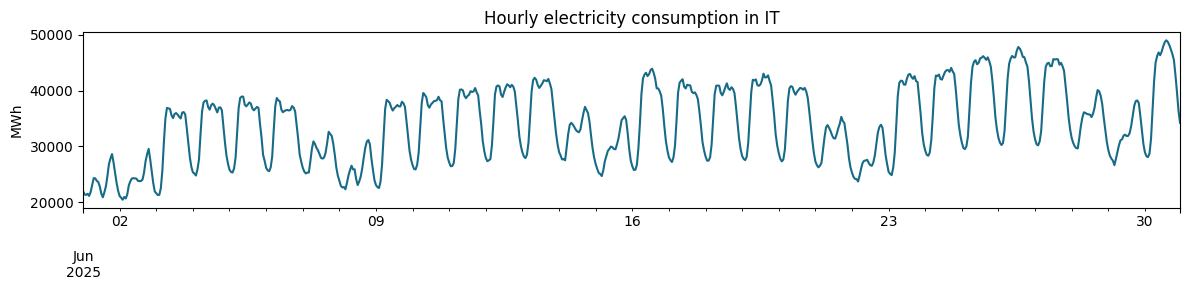

In [44]:
COUNTRY_TO_INSPECT = "IT"
YEAR_TO_INSPECT = 2025

results = elec_noon_june_2025.results(YEAR_TO_INSPECT)

ax = (
    results["consumption_volume"]
    .sel(consumer_country=COUNTRY_TO_INSPECT)
    .to_series()
    .plot(figsize=(12, 3), color="#176B87")
)
ax.set(
    title=f"Hourly electricity consumption in {COUNTRY_TO_INSPECT}",
    xlabel="",
    ylabel=results.attrs.get("volume_unit", "MWh"),
)
plt.tight_layout()